# Significance Testing Evaluation
This notebook evaluates per-drug model performance differences using Wilcoxon signed-rank tests and visualizes the results.

## 1. Setup

In [1]:
#required imports
from sklearn.metrics import roc_auc_score
import glob, os, math, sys,json,time,gc
from pathlib import Path

import numpy as np, pandas as pd, torch
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_1samp
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt




In [ ]:
FOLD_RE = re.compile(r"(.+)_fold(\d+)_preds\.csv$", re.IGNORECASE)
SUFFIXES_TO_STRIP = ["_lasso", "_ridge", "_logreg"]
# ======================
# HELPERS
# ======================
def auc_safe(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)

def clean_drug_name(name):
    for s in SUFFIXES_TO_STRIP:
        if name.endswith(s):
            return name.replace(s, "")
    return name



def collect_folds(model_name, path_pattern):
    """Return per-fold AUCs as rows (drug, model, fold, auc)."""
    rows = []
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for csv_file in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(csv_file.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(csv_file)
                auc = auc_safe(df["label"], df["prob"])
                if not np.isnan(auc):
                    rows.append({
                        "drug": drug,
                        "model": model_name,
                        "fold": fold,
                        "auc": auc
                    })
    return rows

def get_model_folds(path_pattern):
    """Return {drug: {fold: auc}}."""
    folds_dict = {}
    for p in Path().glob(path_pattern):
        if p.is_dir():
            for f in p.rglob("*_fold*_preds.csv"):
                m = FOLD_RE.search(f.name)
                if not m:
                    continue
                drug = clean_drug_name(m.group(1))
                fold = int(m.group(2))
                df = pd.read_csv(f)
                auc = auc_safe(df["label"], df["prob"])
                folds_dict.setdefault(drug, {})[fold] = auc
    return folds_dict


In [ ]:
# ======================
# CONFIG
# ======================
MODEL_PATHS = {
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}

BASELINE_MODEL = "LogReg"
OUT_DIR = "data/latest/cross_val/combined"


# ======================
# MAIN
# ======================
def main():
    all_model_data = {m: get_model_folds(p) for m, p in MODEL_PATHS.items()}
    rows = []
    summaries = []

    for drug in sorted(all_model_data[BASELINE_MODEL].keys()):
        baseline_folds = all_model_data[BASELINE_MODEL][drug]
        base_mean = np.mean(list(baseline_folds.values()))
        base_sd = np.std(list(baseline_folds.values()), ddof=1)

        for model, data in all_model_data.items():
            if drug not in data:
                continue

            folds = data[drug]
            common_folds = sorted(set(baseline_folds) & set(folds))
            aucs = np.array([folds[f] for f in common_folds])

            mean_auc = np.mean(aucs)
            sd_auc = np.std(aucs, ddof=1)
            ci_low = mean_auc - 1.96 * (sd_auc / np.sqrt(len(aucs)))
            ci_high = mean_auc + 1.96 * (sd_auc / np.sqrt(len(aucs)))

            # Wilcoxon test vs baseline
            if model != BASELINE_MODEL:
                base_aucs = np.array([baseline_folds[f] for f in common_folds])
                try:
                    _, p_val = wilcoxon(aucs, base_aucs, alternative="two-sided")
                except ValueError:
                    p_val = np.nan
            else:
                p_val = np.nan

            rows.append({
                "drug": drug,
                "model": model,
                "mean_auc": mean_auc,
                "std_auc": sd_auc,
                "ci_95": f"[{ci_low:.3f},{ci_high:.3f}]",
                "p_vs_baseline": p_val
            })

            # Text summary for report
            if model != BASELINE_MODEL:
                summaries.append(
                    f"For {drug}, the {model} achieved a mean AUC of {mean_auc:.3f} ± {sd_auc:.3f}, "
                    f"compared to {BASELINE_MODEL} ({base_mean:.3f} ± {base_sd:.3f}); "
                    f"Wilcoxon signed-rank test p = {p_val:.3g} (n = {len(common_folds)})."
                )

    # Save table
    df = pd.DataFrame(rows)
    df.to_csv(f"{OUT_DIR}/per_drug_wilcoxon_pairwise.csv", index=False)
    print(f"[OK] Wrote per_drug_wilcoxon_pairwise.csv with {len(df)} rows.")

    # Save text summaries
    with open(f"{OUT_DIR}/per_drug_text_summaries.txt", "w") as f:
        f.write("\n".join(summaries))
    print(f"[OK] Wrote per_drug_text_summaries.txt with {len(summaries)} summaries.")

    # Optional: best model per drug
    winners = (
        df[df["model"] != BASELINE_MODEL]
        .sort_values(["drug", "mean_auc"], ascending=[True, False])
        .groupby("drug")
        .first()
        .reset_index()
    )
    winners.to_csv(f"{OUT_DIR}/best_models_per_drug_wilcoxon.csv", index=False)
    print(f"[OK] Wrote best_models_per_drug_wilcoxon.csv for {len(winners)} drugs.")


if __name__ == "__main__":
    main()


In [10]:
import pandas as pd

# ====== CONFIG ======
INPUT_FILE = "data/latest/cross_val/combined/per_drug_vs_baseline.csv"  #  CSV with columns: drug,model,mean_auc,p_vs_baseline
P_THRESHOLD = 0.05

# ====== LOAD ======
df = pd.read_csv(INPUT_FILE)

# Only keep rows that have a baseline comparison
df_non_base = df[df["model"] != "LogReg"].copy()

# For each drug, find the model with highest mean_auc
winners = (
    df_non_base
    .sort_values(["drug", "mean_auc"], ascending=[True, False])
    .groupby("drug")
    .first()
    .reset_index()
)

# Flag significance
winners["significant"] = winners["p_vs_baseline"] < P_THRESHOLD

# Save
winners.to_csv("data/latest/cross_val/combined/best_models_per_drug.csv", index=False)

# Print nicely
print(winners[["drug", "model", "mean_auc", "p_vs_baseline", "significant"]])


           drug      model  mean_auc  p_vs_baseline  significant
0      amikacin  CNN-PCA10  0.504721         0.0625        False
1   capreomycin        CNN  0.502688         0.1250        False
2    ethambutol  CNN-PCA10  0.916723         0.4375        False
3   ethionamide  CNN-PCA10  0.662774         1.0000        False
4     isoniazid        CNN  0.918305         0.0625        False
5  levofloxacin  CNN-PCA10  0.943803         0.4375        False
6  moxifloxacin  CNN-PCA10  0.845956         0.8125        False
7  pyrazinamide  CNN-PCA10  0.840322         0.8125        False
8    rifampicin        CNN  0.966630         0.3125        False
9  streptomycin        CNN  0.860981         0.3125        False


In [ ]:
from itertools import combinations
from scipy.stats import ttest_rel
import pandas as pd

results = []

for drug, sub in df_plot.groupby("drug"):
    models = sub["model"].unique()
    for m1, m2 in combinations(models, 2):
        a1 = sub[sub["model"] == m1].sort_values("fold")["auc"].values
        a2 = sub[sub["model"] == m2].sort_values("fold")["auc"].values
        if len(a1) == len(a2):  # ensure paired folds
            t_stat, p_val = ttest_rel(a1, a2)
            results.append({
                "drug": drug,
                "model_1": m1,
                "model_2": m2,
                "mean_diff": a1.mean() - a2.mean(),
                "p_value": p_val
            })

compare_df = pd.DataFrame(results)
compare_df["significant"] = compare_df["p_value"] < 0.05
compare_df.to_csv("data/latest/cross_val/paired_ttests_per_drug.csv", index=False)


## 2. Load Model Results

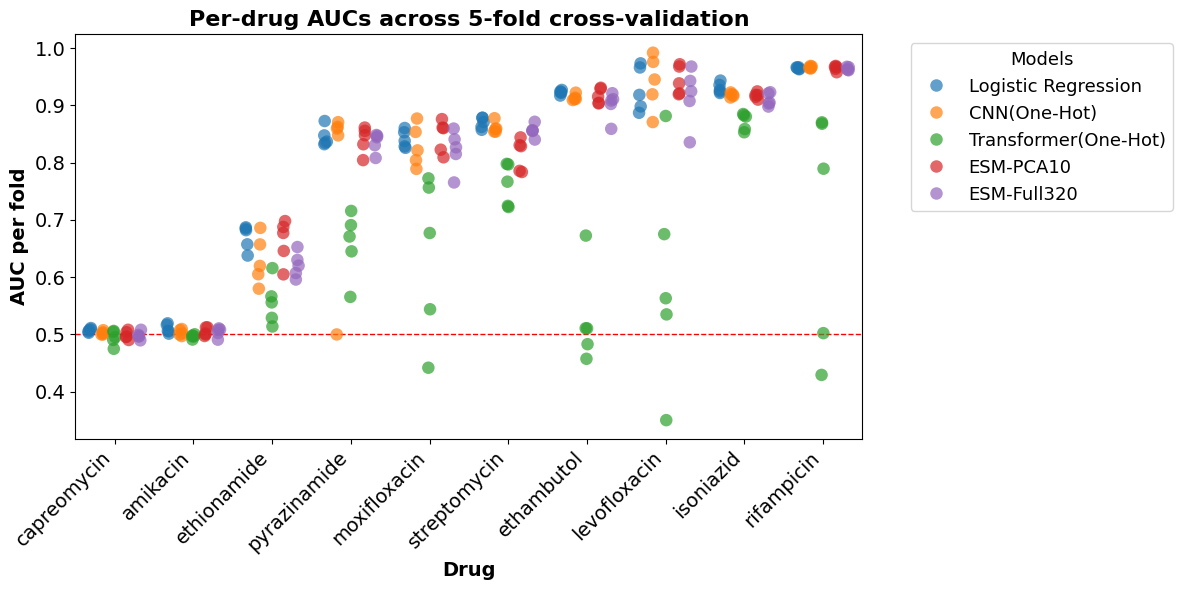

In [ ]:


# === Load and filter cross-validation results ===
df = pd.read_csv("data/latest/cross_val/combined/all_fold_aucs.csv")

# Exclude linear baselines not used in final plot
df_plot = df[~df["model"].str.lower().isin(["lasso", "ridge"])].copy()

# === Rename models for display ===
name_map = {
    "CNN-320":   "ESM-Full320",
    "CNN-PCA10": "ESM-PCA10",
    "LogReg":    "Logistic Regression",
    "CNN":       "CNN(One-Hot)",
    "Transformer": "Transformer(One-Hot)"
}
df_plot["model"] = df_plot["model"].replace(name_map)

# === Define display order for models ===
model_order = [
    "Logistic Regression",
    "CNN(One-Hot)",
    "Transformer(One-Hot)",
    "ESM-PCA10",
    "ESM-Full320"
]
df_plot["model"] = pd.Categorical(df_plot["model"], categories=model_order, ordered=True)

# === Order drugs by mean AUC ===
drug_order = df_plot.groupby("drug")["auc"].mean().sort_values().index

# === Plot per-drug fold-level AUCs ===
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=df_plot,
    x="drug", y="auc",
    hue="model",
    order=drug_order, hue_order=model_order,
    dodge=True, jitter=True, alpha=0.7, size=9
)

# Reference line for random chance
plt.axhline(0.5, color="red", linestyle="--", lw=1)

# Axis styling
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Drug", fontsize=14, weight="bold")
plt.ylabel("AUC per fold", fontsize=14, weight="bold")
plt.title("Per-drug AUCs across 5-fold cross-validation", fontsize=16, weight="bold")

# Legend styling
plt.legend(
    title="Models",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=13
)

# Save figure
plt.tight_layout()
plt.savefig("data/latest/cross_val/combined/per_drug_aucs_renamed.png", dpi=300)
plt.show()


## 4. Summaries & Exports

In [ ]:
# ====== CONFIG ======
MODEL_DIRS = {
    "Lasso": "data/latest/cross_val/regression_cv_sig/*/lasso",
    "Ridge": "data/latest/cross_val/regression_cv_sig/*/ridge",
    "LogReg": "data/latest/cross_val/regression_cv_sig/*/logreg",
    "CNN-PCA10": "data/latest/cross_val/esm_cv_sig/*/pca",
    "CNN-320": "data/latest/cross_val/esm_cv_sig/*/full",
    "CNN": "data/latest/cross_val/cnn_cv_sig",
    "Transformer": "data/latest/cross_val/transformer_cv_sig"
}


all_folds = []
for model_name, path_pattern in MODEL_DIRS.items():
    rows = collect_folds(model_name, path_pattern)
    all_folds.extend(rows)

# Save per-fold file
fold_df = pd.DataFrame(all_folds)
fold_df.to_csv("data/latest/cross_val/combined/all_fold_aucs.csv", index=False)
print(f"[OK] Wrote all_fold_aucs.csv with {len(fold_df)} rows.")



## 6. Appendix / Debug Checks

In [2]:
#declare gene-drug map
single_drugs = {
    "rifampicin" : ["rpoB"],
    "pyrazinamide": ["pncA"],
    "capreomycin" : ["tlyA"],
    "amikacin"    : ["eis"]
}

multi_drugs = {
    "streptomycin": ["rpsL", "gid"],
    "isoniazid"   : ["katG", "inhA"],
    "ethionamide" : ["ethA", "ethR","inhA"],
    "ethambutol"  : ["embC","embA","embB"],
    "moxifloxacin": ["gyrA", "gyrB"],
    "levofloxacin": ["gyrA", "gyrB"]
}

all_drugs = {**single_drugs, **multi_drugs}   # merge dicts

## generate per fold prediction

In [ ]:
# Example: regenerate for streptomycin, mean-compressed (dim=1)
regenerate_esm_fold_preds(
    gene=None,           # unused for single-gene branch; keep for API parity
    drug="streptomycin",
    mode="mean",         # "pca" | "mean" | "full"
    in_dim=1,
    out_root="data/latest/results_cv",  # same root  used during CV training
    n_folds=5,
    seed=42,
    batch_size=32
)


## prediction task